In [33]:
import importlib
import sys
sys.path.append('../code')

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import pandas as pd

import SeaLevelContrib as slc

import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('retina')

In [34]:
importlib.reload(slc)

<module 'SeaLevelContrib' from 'C:\\Users\\kyrab\\Github\\SLBudget\\notebooks\\../code\\SeaLevelContrib.py'>

In [35]:
def rotate_longitude(ds):
    '''Rotate the longitude of an xarray dataset from [0,360] to [-180,180]'''
    
    if 'lon' in ds.dims:
        lon = 'lon'
    elif 'longitude' in ds.dims:
        lon = 'longitude'
    else:
        print('Longitude not found in dimensions')
        
    ds[lon] = np.where(ds[lon]>180, ds[lon]-360, ds[lon])
    ds = ds.reindex({ lon : np.sort(ds[lon])})
    
    return ds


In [36]:
import os

fpath = '../outputs/Gravis_Antarctica/Gravis_gre.nc'
print(os.path.exists(fpath))
print(os.path.getsize(fpath))  # should be > 0 bytes


True
11937964


In [37]:
fred_dir = '../data/Frederikse2020/'
Fred_ant_ds = xr.open_dataset(f'{fred_dir}AIS.nc')
#Fred_ant_ds['AIS_rsl_mean'].isel(time=-1).plot()
#plt.show()

fred2 = rotate_longitude(Fred_ant_ds)
#display(fred2)
#fred2['AIS_rsl_mean'].isel(time=-1).plot()
#plt.show()
Gravis_dir = '../outputs/Gravis_Antarctica/'
Gravis_ant_ds = xr.open_dataset(f'{Gravis_dir}Gravis_Ant_new_weighted.nc')
display(Gravis_ant_ds)
Gravis_gre_ds = xr.open_dataset(f'{Gravis_dir}Gravis_gre.nc')
display(Gravis_ant_ds)



<xarray.Dataset> Size: 12MB
Dimensions:     (time: 23, lat: 180, lon: 360)
Coordinates:
  * lon         (lon) float64 3kB 0.5 1.5 2.5 3.5 ... 356.5 357.5 358.5 359.5
  * lat         (lat) float64 1kB -89.5 -88.5 -87.5 -86.5 ... 87.5 88.5 89.5
  * time        (time) int64 184B 2002 2003 2004 2005 ... 2021 2022 2023 2024
Data variables:
    AIS_Gravis  (time, lat, lon) float64 12MB ...
    Meanslr     (time) float64 184B ...
Attributes:
    Info:     Based on Gravis data and created using the gravity toolkit

<xarray.Dataset> Size: 12MB
Dimensions:     (time: 23, lat: 180, lon: 360)
Coordinates:
  * lon         (lon) float64 3kB 0.5 1.5 2.5 3.5 ... 356.5 357.5 358.5 359.5
  * lat         (lat) float64 1kB -89.5 -88.5 -87.5 -86.5 ... 87.5 88.5 89.5
  * time        (time) int64 184B 2002 2003 2004 2005 ... 2021 2022 2023 2024
Data variables:
    AIS_Gravis  (time, lat, lon) float64 12MB ...
    Meanslr     (time) float64 184B ...
Attributes:
    Info:     Based on Gravis data and created using the gravity toolkit

In [38]:
tg_id = [20, 22, 23, 24, 25, 32]
#Extract latitude and longitude from a tide gauge station from the list. 
tg_coord = slc.tg_lat_lon(tg_id[0])
print(tg_coord)

TWS = slc.contrib_frederikse2020(tg_coord, 'tws', extrap=True)
ANT = slc.contrib_frederikse2020(tg_coord, 'AIS', extrap=True)
GRE = slc.contrib_frederikse2020(tg_coord, 'GrIS', extrap=True)
GLA = slc.contrib_frederikse2020(tg_coord, 'glac', extrap=True)

glo_steric_df = slc.contrib_frederikse2020_glob('GloSteric', extrap=True)


ds = Gravis_ant_ds
ds2 = Gravis_gre_ds

sel_da = ds['AIS_Gravis'].ffill('lon', 3).bfill('lon', 3)
sel_da2 = ds2['AIS_Gravis'].ffill('lon', 3).bfill('lon', 3)
# Convert from mm to cm not needed because is already in cm

loc_da = sel_da.sel(lat = tg_coord[0], 
                    lon = tg_coord[1], 
                    method = 'nearest')
loc_da2 = sel_da2.sel(lat = tg_coord[0], 
                    lon = tg_coord[1], 
                    method = 'nearest')

fr_name = {'tws' : 'TWS', 
       'AIS' : 'Antarctica', 
       'GrIS' : 'Greenland', 
       'glac' : 'Glaciers',
          'grav': 'Ant_gravis',
          'grav2': 'Gre_gravis'}


GRAVANT = loc_da.squeeze().reset_coords(drop=True).to_dataframe(name=fr_name['grav'])    
GRAVGRE = loc_da2.squeeze().reset_coords(drop=True).to_dataframe(name=fr_name['grav2'])    

''' 
EXTRAPOLATE OPTION
nby = 10
trend = np.polyfit(GRAVANT.index[-nby:], GRAVANT.iloc[-nby:], 1)
for i in range(7):
    GRAVANT.loc[GRAVANT.index.max() + 1] = (trend[1]+trend[0]*(GRAVANT.index.max()+1))
'''


(np.float64(51.442222), np.float64(3.596111))


' \nEXTRAPOLATE OPTION\nnby = 10\ntrend = np.polyfit(GRAVANT.index[-nby:], GRAVANT.iloc[-nby:], 1)\nfor i in range(7):\n    GRAVANT.loc[GRAVANT.index.max() + 1] = (trend[1]+trend[0]*(GRAVANT.index.max()+1))\n'

      Antarctica
time            
1900   -0.850000
1901   -0.845000
1902   -0.840000
1903   -0.835000
1904   -0.830000
...          ...
2021    0.480818
2022    0.527727
2023    0.574636
2024    0.621545
2025    0.668455

[126 rows x 1 columns]
-0.25


<xarray.DataArray (time: 23, lat: 180, lon: 360)> Size: 12MB
array([[[       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        ...,
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan]],

       [[0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ],
        [0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ],
        [0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ],
...
        [1.18499036, 1.18423283, 1.182042  , ..., 1.17852944,
         1.18205986, 1.18425518],
        [1.13426174, 1.12863517, 1.12386181, ..., 1.15488825,
         1.14753847, 1.1406111 ],
        [1.19240387, 1.18866567, 1.18489037, ..., 1.20329413,
         1.19972836, 1.19609485]],

       [[0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ],
        [0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ],
        [0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ],
        ...,
        [1.1852704 , 1.18395369, 1.18123085, ..., 1.18029972,
         1.18339809, 1.18508599],
        [1.13416619, 1.12859523, 1.12390083, ..., 1.15477227,
         1.14740476, 1.14048417],
        [1.19762493, 1.19405867, 1.19044722, ..., 1.20795438,
         1.20458268, 1.20113622]]], shape=(23, 180, 360))
Coordinates:
  * lon      (lon) float64 3kB 0.5 1.5 2.5 3.5 4.5 ... 356.5 357.5 358.5 359.5
  * lat      (lat) float64 1kB -89.5 -88.5 -87.5 -86.5 ... 86.5 87.5 88.5 89.5
  * time     (time) int64 184B 2002 2003 2004 2005 2006 ... 2021 2022 2023 2024

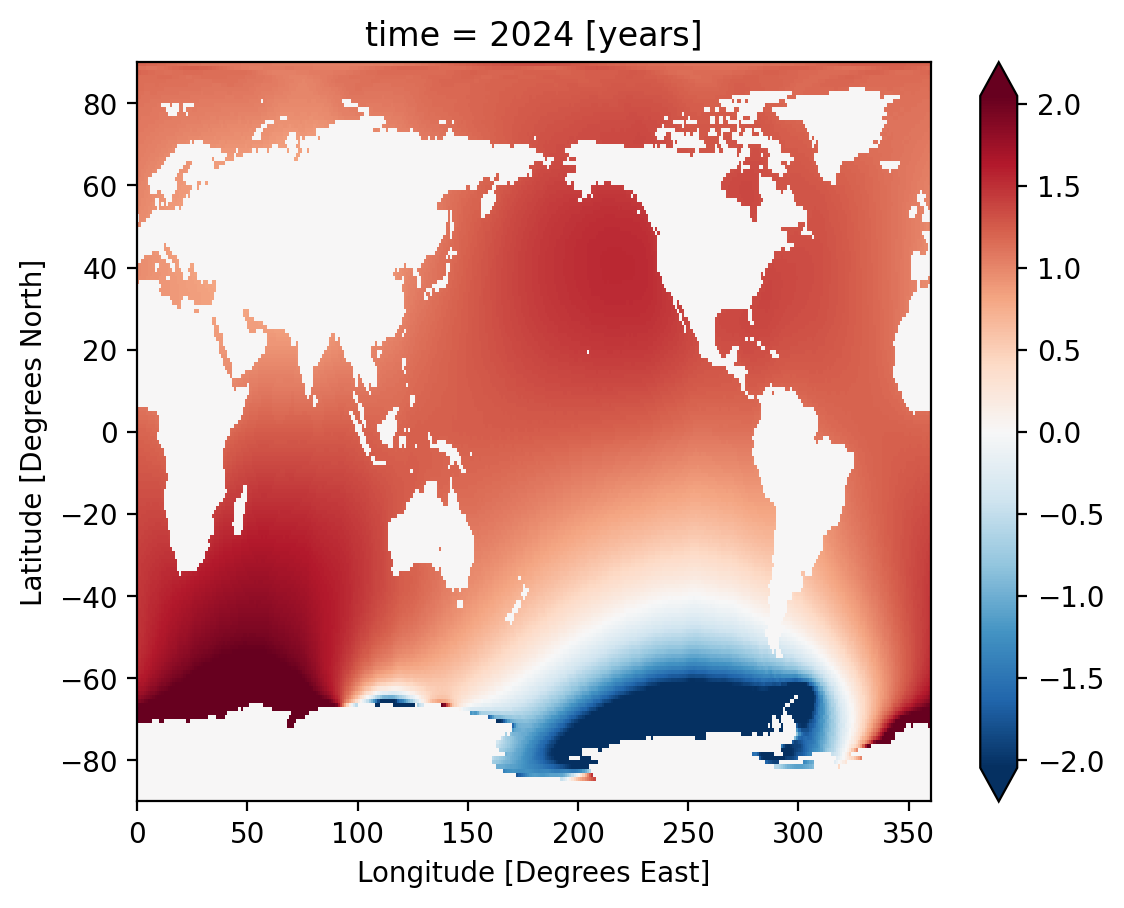

In [39]:
print(ANT)

#print(ANT.loc[2002])
print(ANT.loc[2002, "Antarctica"])


#display(Gravis_ant_ds['Meanslr'])

#display(Gravis_ant_ds['AIS_Gravis'])


fractionmean = Gravis_ant_ds['AIS_Gravis']/Gravis_ant_ds['Meanslr'] 
display(fractionmean) 
fractionmean.isel(time=-1).plot(robust=True)


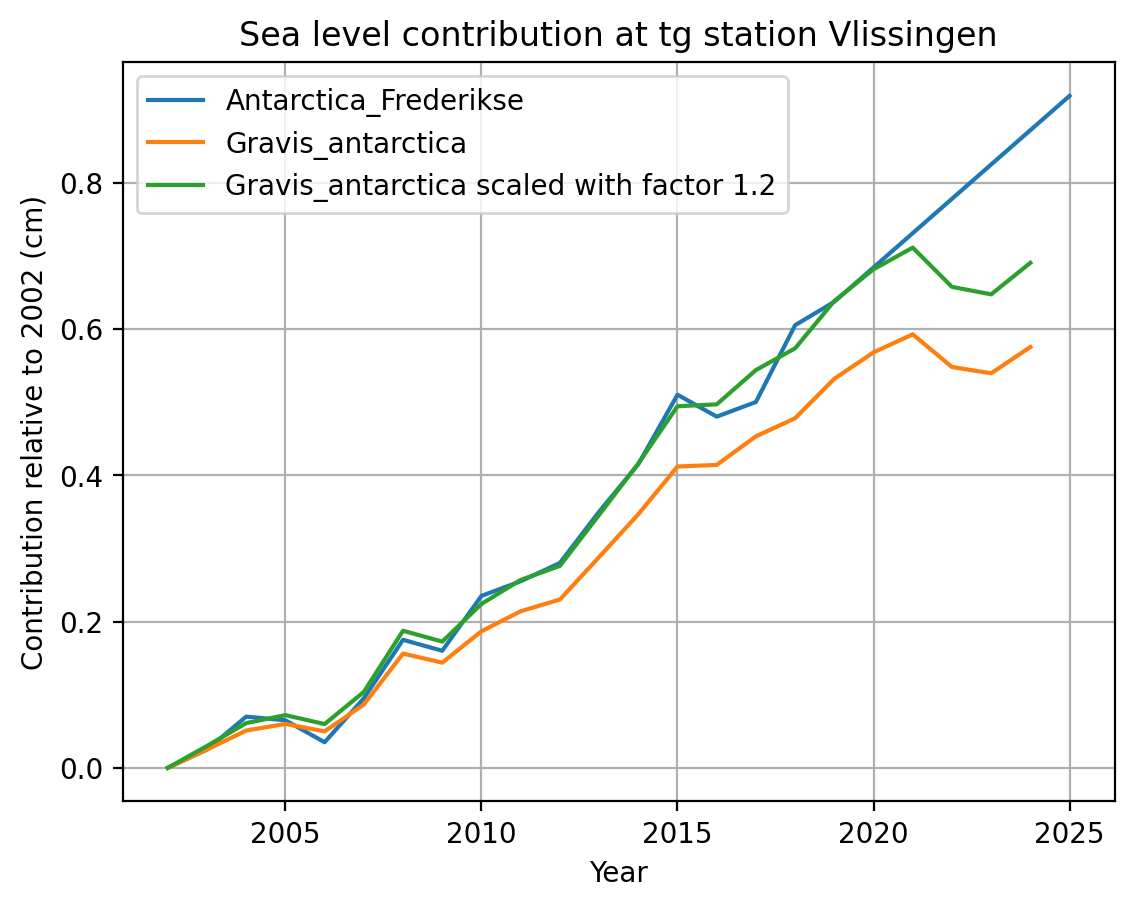

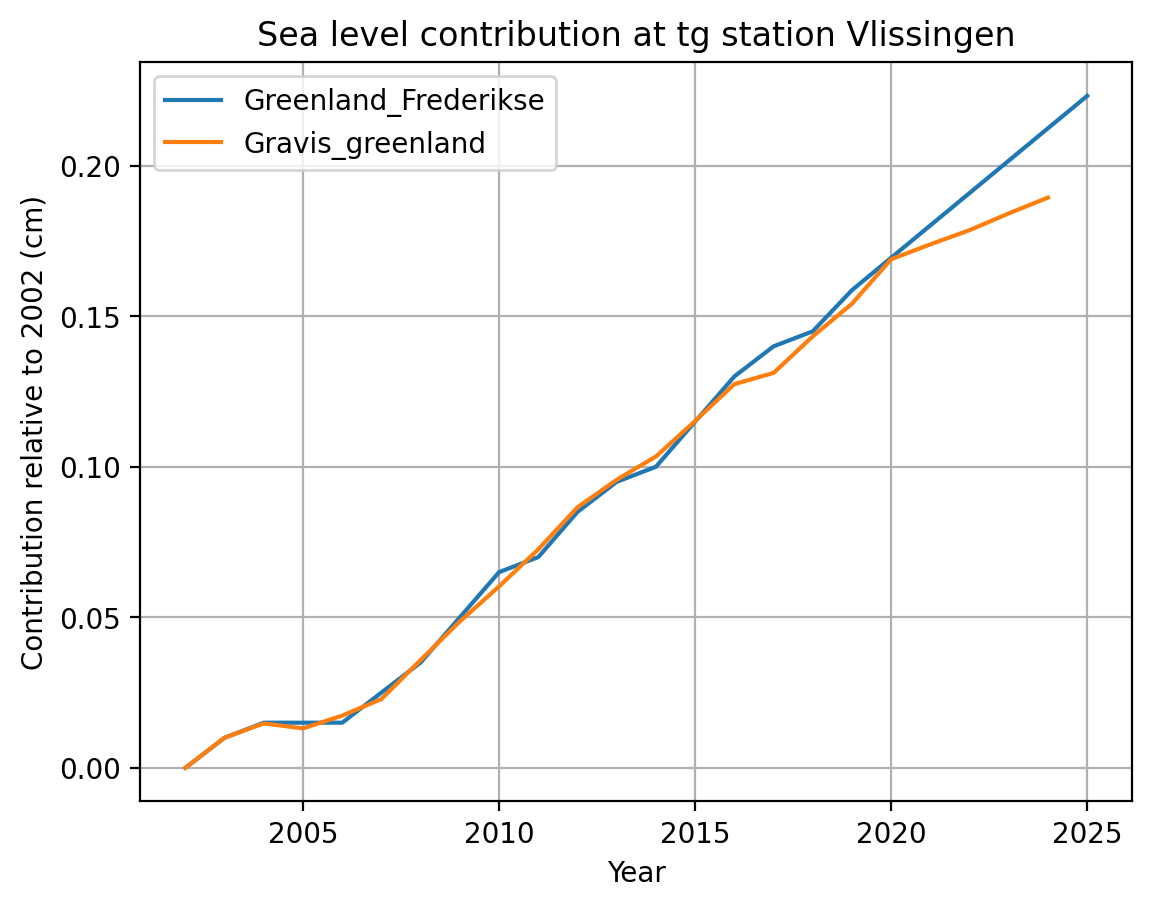

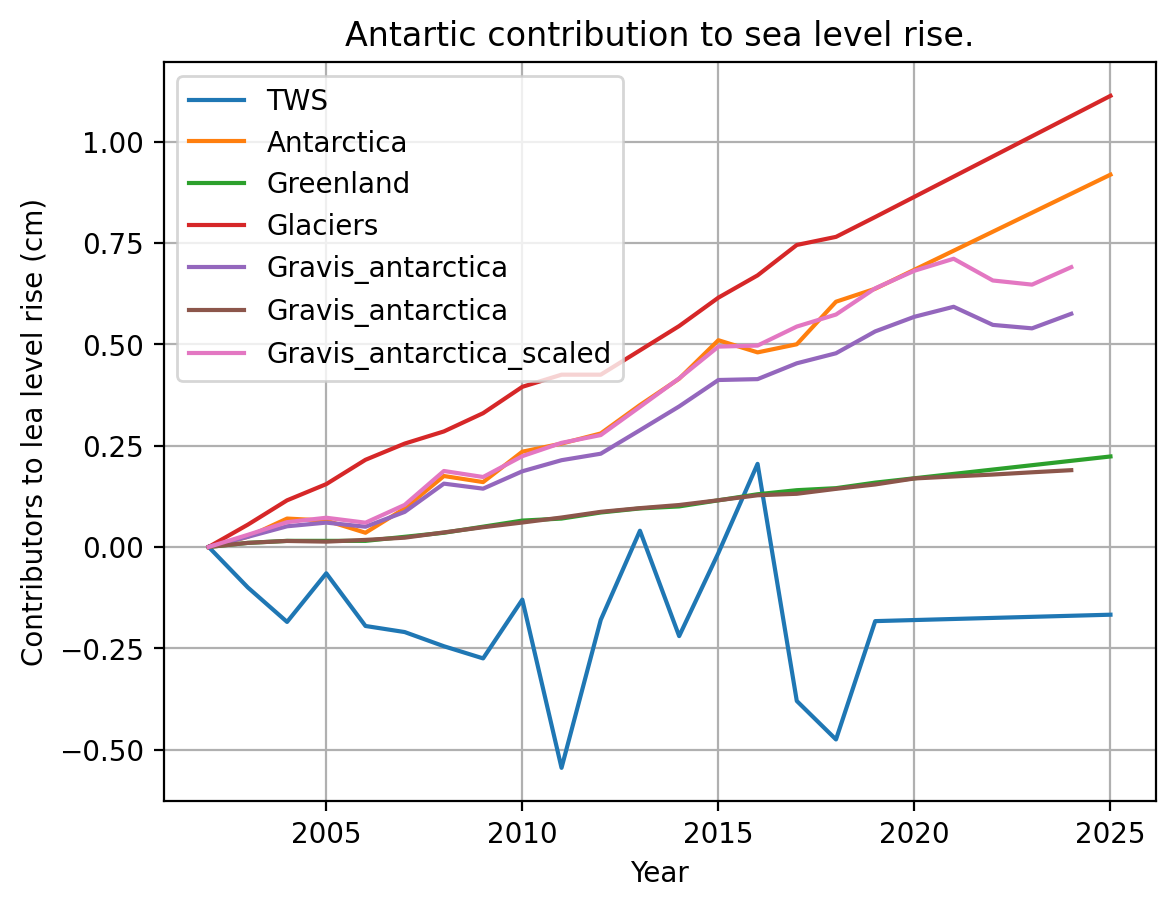

In [40]:
#plt.plot(TWS.loc[2000:], label='TWS')
plt.plot((ANT- ANT.loc[2002, "Antarctica"]).loc[2002:], label='Antarctica_Frederikse')
#plt.plot(GRE.loc[2000:], label='Greenland')
#plt.plot(GLA.loc[2000:], label='Glaciers')
plt.plot(GRAVANT.loc[2002:], label='Gravis_antarctica')
plt.plot(GRAVANT.loc[2002:]*1.2, label='Gravis_antarctica scaled with factor 1.2')
#plt.plot(glo_steric_df.loc[2000:], label='Global Steric')




plt.legend()
plt.xlabel('Year')
plt.title('Sea level contribution at tg station Vlissingen')
plt.ylabel('Contribution relative to 2002 (cm)')
plt.grid(True)
plt.show()




plt.plot((GRE- GRE.loc[2002, "Greenland"]).loc[2002:], label='Greenland_Frederikse')
#plt.plot(GRE.loc[2000:], label='Greenland')
#plt.plot(GLA.loc[2000:], label='Glaciers')
plt.plot(GRAVGRE.loc[2002:], label='Gravis_greenland')
#plt.plot(glo_steric_df.loc[2000:], label='Global Steric')




plt.legend()
plt.xlabel('Year')
plt.title('Sea level contribution at tg station Vlissingen')
plt.ylabel('Contribution relative to 2002 (cm)')
plt.grid(True)
plt.show()




plt.plot((TWS-TWS.loc[2002, "TWS"]).loc[2002:], label='TWS')
plt.plot((ANT- ANT.loc[2002, "Antarctica"]).loc[2002:], label='Antarctica')
plt.plot((GRE-GRE.loc[2002, "Greenland"]).loc[2002:], label='Greenland')
plt.plot((GLA-GLA.loc[2002, "Glaciers"]).loc[2002:], label='Glaciers')
plt.plot(GRAVANT.loc[2002:], label='Gravis_antarctica')
plt.plot(GRAVGRE.loc[2002:], label='Gravis_antarctica')
plt.plot(GRAVANT.loc[2002:]*1.2, label='Gravis_antarctica_scaled')
#plt.plot((glo_steric_df-glo_steric_df.loc[2002, 'Global Steric']).loc[2002:], label='Global Steric')




plt.legend()
plt.xlabel('Year')
plt.ylabel('Contributors to lea level rise (cm)')
plt.title('Antartic contribution to sea level rise.')
plt.grid(True)
plt.show()


time
2002         NaN
2003    1.124065
2004    1.059019
2005    1.043147
2006    1.018514
2007    1.029615
2008    1.036669
2009    0.974730
2010    0.970004
2011    0.948649
2012    0.950445
2013    0.964247
2014    0.973219
2015    0.985839
2016    0.977245
2017    0.987113
2018    0.975402
2019    0.982949
2020    0.986194
2021    0.978637
2022    0.960089
2023    0.955506
2024    0.953780
Name: Ant_gravis, dtype: float64

time
2002         NaN
2003    1.124065
2004    1.059019
2005    1.043147
2006    1.018514
2007    1.029615
2008    1.036669
2009    0.974730
2010    0.970004
2011    0.948649
2012    0.950445
2013    0.964247
2014    0.973219
2015    0.985839
2016    0.977245
2017    0.987113
2018    0.975402
2019    0.982949
2020    0.986194
2021    0.978637
2022    0.960089
2023    0.955506
2024    0.953780
Name: Fractom (sea level rise / global mean ), dtype: float64

,Sea level rise vlissingen,Mean sea level rise,Fractom (sea level rise / global mean )
time,,,
2002,0.000000,0.000000,NaN
2003,0.024918,0.022168,1.124065
2004,0.050959,0.048119,1.059019
2005,0.060034,0.057551,1.043147
2006,0.049864,0.048957,1.018514
2007,0.086453,0.083967,1.029615
2008,0.156157,0.150633,1.036669
2009,0.143774,0.147501,0.974730
2010,0.186670,0.192442,0.970004


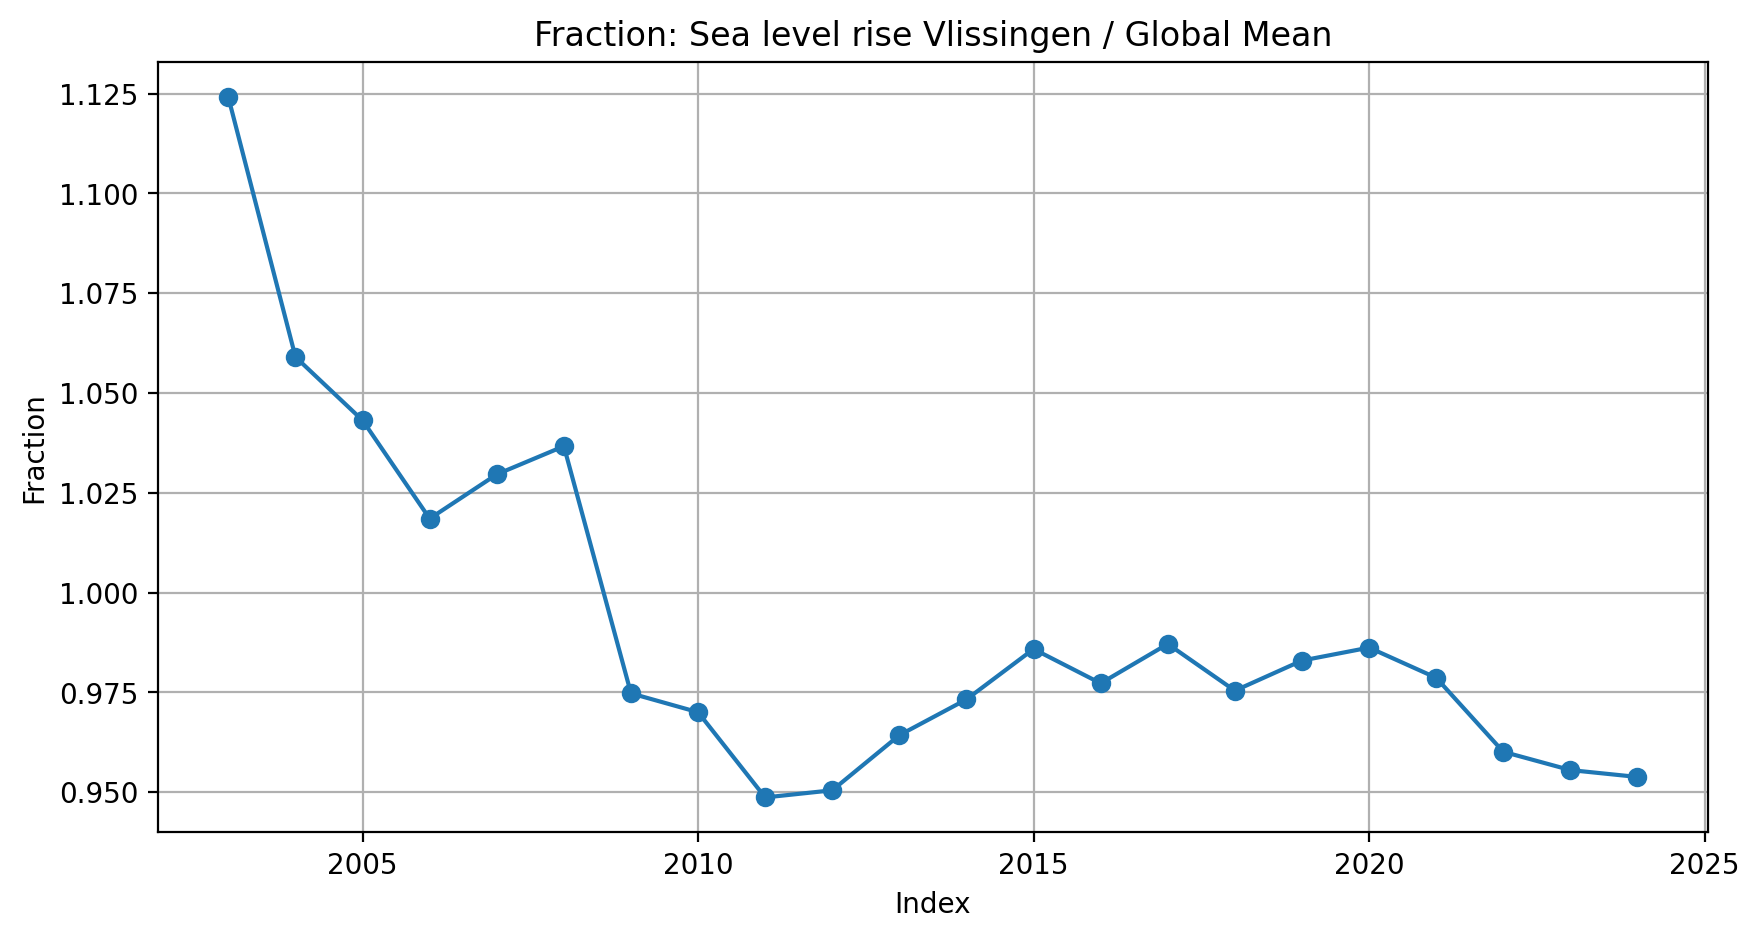

In [41]:
#display(GRAVANT)
fraction = GRAVANT['Ant_gravis']/Gravis_ant_ds['Meanslr'] 
display(fraction)


# Combine the three values into one DataFrame
combined = pd.DataFrame({
    'Sea level rise vlissingen': GRAVANT['Ant_gravis'],
    'Mean sea level rise': Gravis_ant_ds['Meanslr'],
    'Fractom (sea level rise / global mean )': GRAVANT['Ant_gravis'] / Gravis_ant_ds['Meanslr']
})

display(combined['Fractom (sea level rise / global mean )'])
display(combined)

        

# Drop rows where the fraction is NaN
valid_data = combined.dropna(subset=['Fractom (sea level rise / global mean )'])

# Plot the fraction
plt.figure(figsize=(10, 5))
plt.plot(valid_data.index, valid_data['Fractom (sea level rise / global mean )'], marker='o')

plt.title('Fraction: Sea level rise Vlissingen / Global Mean')
plt.xlabel('Index')
plt.ylabel('Fraction')
plt.grid(True)
plt.show()